## Importación de Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras import models
from keras import layers
from keras.utils import to_categorical
from keras.datasets import reuters

## División de Datos

In [2]:
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


## Explorando Data

In [44]:
train_data

array([list([1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]),
       list([1, 3267, 699, 3434, 2295, 56, 2, 7511, 9, 56, 3906, 1073, 81, 5, 1198, 57, 366, 737, 132, 20, 4093, 7, 2, 49, 2295, 2, 1037, 3267, 699, 3434, 8, 7, 10, 241, 16, 855, 129, 231, 783, 5, 4, 587, 2295, 2, 2, 775, 7, 48, 34, 191, 44, 35, 1795, 505, 17, 12]),
       list([1, 53, 12, 284, 15, 14, 272, 26, 53, 959, 32, 818, 15, 14, 272, 26, 39, 684, 70, 11, 14, 12, 3886, 18, 180, 183, 187, 70, 11, 14, 102, 32, 11, 29, 53, 44, 704, 15, 14, 19, 758, 15, 53, 959, 47, 1013, 15, 14, 19, 132, 15, 39, 965, 32, 11, 14, 147, 72, 11, 180, 183, 187, 44, 11, 14, 102, 19, 11, 123, 186, 90, 67, 960, 4, 78, 13, 68, 467, 511, 110,

In [43]:
len(train_data[5])

116

In [3]:
train_data.shape

(8982,)

In [4]:
test_data.shape

(2246,)

In [5]:
word_index = reuters.get_word_index()

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 1s 2us/step


In [6]:
word_index

{'mdbl': 10996,
 'fawc': 16260,
 'degussa': 12089,
 'woods': 8803,
 'hanging': 13796,
 'localized': 20672,
 'sation': 20673,
 'chanthaburi': 20675,
 'refunding': 10997,
 'hermann': 8804,
 'passsengers': 20676,
 'stipulate': 20677,
 'heublein': 8352,
 'screaming': 20713,
 'tcby': 16261,
 'four': 185,
 'grains': 1642,
 'broiler': 20680,
 'wooden': 12090,
 'wednesday': 1220,
 'highveld': 13797,
 'duffour': 7593,
 '0053': 20681,
 'elections': 3914,
 '270': 2563,
 '271': 3551,
 '272': 5113,
 '273': 3552,
 '274': 3400,
 'rudman': 7975,
 '276': 3401,
 '277': 3478,
 '278': 3632,
 '279': 4309,
 'dormancy': 9381,
 'errors': 7247,
 'deferred': 3086,
 'sptnd': 20683,
 'cooking': 8805,
 'stratabit': 20684,
 'designing': 16262,
 'metalurgicos': 20685,
 'databank': 13798,
 '300er': 20686,
 'shocks': 20687,
 'nawg': 7972,
 'tnta': 20688,
 'perforations': 20689,
 'affiliates': 2891,
 '27p': 20690,
 'ching': 16263,
 'china': 595,
 'wagyu': 16264,
 'affiliated': 3189,
 'chino': 16265,
 'chinh': 16266,
 '

In [7]:
reverse_word_index=dict([(value, key) for (key, value) in word_index.items()])

In [8]:
for i in train_data[3]:
    print(reverse_word_index.get(i-3, "?")) # Si no encuentra la palabra, imprime "?"

?
the
farmers
home
administration
the
u
s
agriculture
department's
farm
lending
arm
could
lose
about
seven
billion
dlrs
in
outstanding
principal
on
its
severely
?
borrowers
or
about
one
fourth
of
its
farm
loan
portfolio
the
general
accounting
office
gao
said
in
remarks
prepared
for
delivery
to
the
senate
agriculture
committee
brian
crowley
senior
associate
director
of
gao
also
said
that
a
preliminary
analysis
of
proposed
changes
in
?
financial
eligibility
standards
indicated
as
many
as
one
half
of
?
borrowers
who
received
new
loans
from
the
agency
in
1986
would
be
?
under
the
proposed
system
the
agency
has
proposed
evaluating
?
credit
using
a
variety
of
financial
ratios
instead
of
relying
solely
on
?
ability
senate
agriculture
committee
chairman
patrick
leahy
d
vt
?
the
proposed
eligibility
changes
telling
?
administrator
?
clark
at
a
hearing
that
they
would
mark
a
dramatic
shift
in
the
agency's
purpose
away
from
being
farmers'
lender
of
last
resort
toward
becoming
a
big
city
bank
but


In [9]:
train_labels[0]

np.int64(3)

## Vectorización de data

In [10]:
def vectorizar_secuencia(secuencia, longitud=10000):
    resultado = np.zeros((len(secuencia), longitud))
    for i, sec in enumerate(secuencia):
        resultado[i, sec] = 1
    return resultado

In [11]:
x_train=vectorizar_secuencia(train_data)
x_test=vectorizar_secuencia(test_data)

In [12]:
x_test.shape

(2246, 10000)

In [13]:
x_train.shape

(8982, 10000)

In [14]:
train_labels[2]

np.int64(3)

In [15]:
train_labels.shape

(8982,)

In [16]:
y_train= to_categorical(train_labels)
y_test= to_categorical(test_labels)

In [17]:
y_train.shape

(8982, 46)

In [18]:
y_train[0]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [19]:
y_test.shape

(2246, 46)

## Creación de Capas 

In [20]:
model=models.Sequential()
model.add(layers.Dense(64, activation="relu", input_shape=(10000,)))
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(46, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compilación del Modelo

In [21]:
model.compile(optimizer="rmsprop", 
               loss="categorical_crossentropy", 
               metrics=["accuracy"])

## Entrenamiento del Modelo

In [22]:
modelo=model.fit(x_train, y_train, epochs=30, batch_size=512, validation_split=0.2)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - accuracy: 0.5022 - loss: 2.9603 - val_accuracy: 0.6093 - val_loss: 2.0407
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6665 - loss: 1.6755 - val_accuracy: 0.6461 - val_loss: 1.5295
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7201 - loss: 1.2802 - val_accuracy: 0.7040 - val_loss: 1.3230
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7630 - loss: 1.0654 - val_accuracy: 0.7462 - val_loss: 1.1965
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8026 - loss: 0.9176 - val_accuracy: 0.7412 - val_loss: 1.1454
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8281 - loss: 0.7907 - val_accuracy: 0.7579 - val_loss: 1.0806
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8569 - loss: 0.6785 - val_accuracy: 0.7791 - val_loss: 1.0220
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8809 - loss: 0.5828 - val_accuracy: 0.7513 - 

In [23]:
modelo_dict=modelo.history
print(modelo_dict)

{'accuracy': [0.5021572709083557, 0.666527509689331, 0.7201113700866699, 0.7629784345626831, 0.8026443719863892, 0.8281141519546509, 0.8569241762161255, 0.8808628916740417, 0.8933889865875244, 0.913013219833374, 0.9244258999824524, 0.9316632151603699, 0.9398747682571411, 0.9437717199325562, 0.9504523277282715, 0.9526792168617249, 0.9556019306182861, 0.9564370512962341, 0.9582463502883911, 0.9600556492805481, 0.9603340029716492, 0.9610299468040466, 0.9614474773406982, 0.9627000689506531, 0.9617258310317993, 0.9631175994873047, 0.9639526605606079, 0.9635351300239563, 0.9647877812385559, 0.9615866541862488], 'loss': [2.960345506668091, 1.6754724979400635, 1.280212163925171, 1.0654234886169434, 0.9175654053688049, 0.7906946539878845, 0.6785057187080383, 0.5827892422676086, 0.500819742679596, 0.43063628673553467, 0.3700430989265442, 0.3282157778739929, 0.2805931568145752, 0.25363031029701233, 0.21915775537490845, 0.19867579638957977, 0.181851327419281, 0.16841886937618256, 0.155775606632232

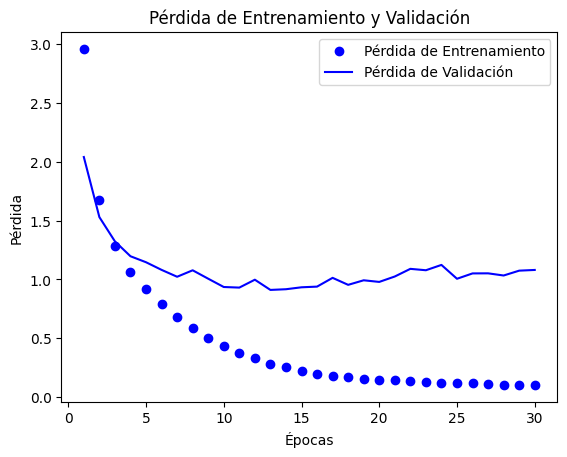

In [24]:
loss_values = modelo_dict['loss']
val_loss_values = modelo_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Pérdida de Entrenamiento')
plt.plot(epochs, val_loss_values, 'b', label='Pérdida de Validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

## Mejoramiento del modelo

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 0.4848 - loss: 2.8448 - val_accuracy: 0.5787 - val_loss: 2.0112
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6639 - loss: 1.7339 - val_accuracy: 0.6784 - val_loss: 1.6275
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7326 - loss: 1.4133 - val_accuracy: 0.7218 - val_loss: 1.4587
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7755 - loss: 1.2248 - val_accuracy: 0.6956 - val_loss: 1.4320
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8000 - loss: 1.0920 - val_accuracy: 0.7524 - val_loss: 1.3243
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8274 - loss: 0.9824 - val_accuracy: 0.7613 - val_loss: 1.2597
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8493 - loss: 0.8879 - val_accuracy: 0.7741 - val_loss: 1.2091
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8675 - loss: 0.8134 - val_accuracy: 0.7579 - 

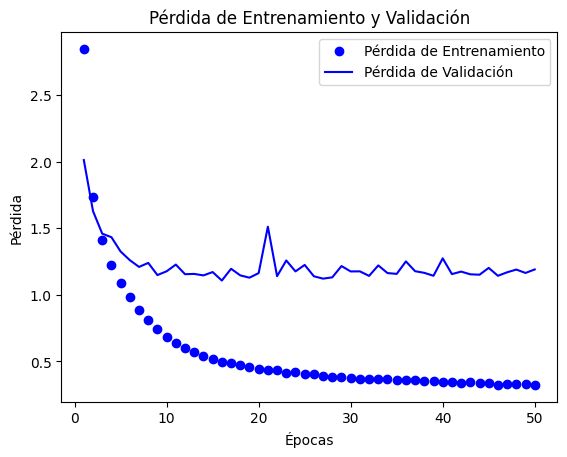

In [25]:
from keras import regularizers


model2=models.Sequential()
model2.add(layers.Dense(64, activation="relu", input_shape=(10000,), kernel_regularizer=regularizers.l2(0.001)))
model2.add(layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)))
model2.add(layers.Dense(46, activation="softmax"))

model2.compile(optimizer="rmsprop", 
               loss="categorical_crossentropy", 
               metrics=["accuracy"])

modelo2=model2.fit(x_train, y_train, epochs=50, batch_size=512, validation_split=0.2)

modelo_dict2=modelo2.history
print(modelo_dict2)

loss_values2 = modelo_dict2['loss']
val_loss_values2 = modelo_dict2['val_loss']
epochs = range(1, len(loss_values2) + 1)

plt.plot(epochs, loss_values2, 'bo', label='Pérdida de Entrenamiento')
plt.plot(epochs, val_loss_values2, 'b', label='Pérdida de Validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.4241 - loss: 2.9545 - val_accuracy: 0.6216 - val_loss: 2.1206
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5823 - loss: 1.9908 - val_accuracy: 0.6383 - val_loss: 1.7379
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6451 - loss: 1.7124 - val_accuracy: 0.6995 - val_loss: 1.5380
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6835 - loss: 1.5289 - val_accuracy: 0.7040 - val_loss: 1.4454
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7162 - loss: 1.3964 - val_accuracy: 0.7318 - val_loss: 1.3574
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7342 - loss: 1.3103 - val_accuracy: 0.7262 - val_loss: 1.3537
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7569 - loss: 1.2151 - val_accuracy: 0.7540 - val_loss: 1.2726
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7748 - loss: 1.1430 - val_accuracy: 0.7674 - 

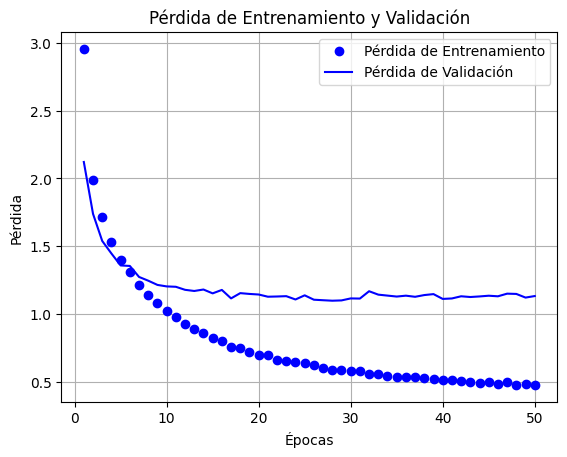

In [26]:
model3=models.Sequential()
model3.add(layers.Dense(64, activation="relu", input_shape=(10000,), kernel_regularizer=regularizers.l2(0.001)))
model3.add(layers.Dropout(0.5))
model3.add(layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)))
model3.add(layers.Dense(46, activation="softmax"))

model3.compile(optimizer="rmsprop", 
               loss="categorical_crossentropy", 
               metrics=["accuracy"])

modelo3=model3.fit(x_train, y_train, epochs=50, batch_size=512, validation_split=0.2)

modelo_dict3=modelo3.history
print(modelo_dict3)

loss_values3 = modelo_dict3['loss']
val_loss_values3 = modelo_dict3['val_loss']
epochs = range(1, len(loss_values3) + 1)

plt.plot(epochs, loss_values3, 'bo', label='Pérdida de Entrenamiento')
plt.plot(epochs, val_loss_values3, 'b', label='Pérdida de Validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.grid()
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 260ms/step - accuracy: 0.4313 - loss: 3.0777 - val_accuracy: 0.5748 - val_loss: 2.2088
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5741 - loss: 2.0820 - val_accuracy: 0.6160 - val_loss: 1.8070
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6301 - loss: 1.7530 - val_accuracy: 0.6867 - val_loss: 1.6005
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6661 - loss: 1.5904 - val_accuracy: 0.6984 - val_loss: 1.4958
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6935 - loss: 1.4614 - val_accuracy: 0.7112 - val_loss: 1.4146
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7115 - loss: 1.3669 - val_accuracy: 0.7173 - val_loss: 1.3696
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7308 - loss: 1.2912 - val_accuracy: 0.7429 - val_loss: 1.3024
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7473 - loss: 1.2235 - val_accuracy: 0.7451 - 

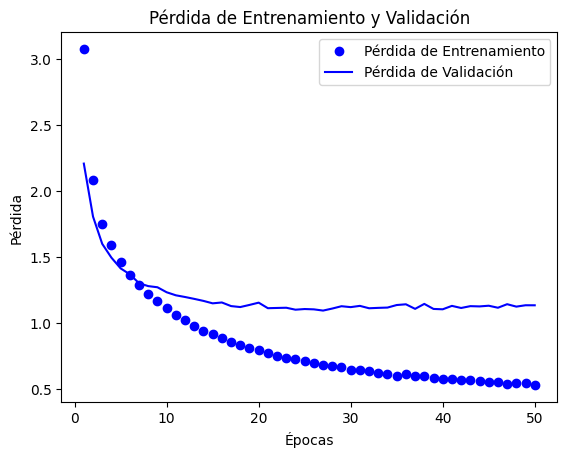

In [27]:
from keras import regularizers


model4=models.Sequential()
model4.add(layers.Dense(50, activation="relu", input_shape=(10000,), kernel_regularizer=regularizers.l2(0.001)))
model4.add(layers.Dropout(0.5))
model4.add(layers.Dense(50, activation="relu", kernel_regularizer=regularizers.l2(0.001)))
model4.add(layers.Dense(46, activation="softmax"))

model4.compile(optimizer="rmsprop", 
               loss="categorical_crossentropy", 
               metrics=["accuracy"])

modelo4=model4.fit(x_train, y_train, epochs=50, batch_size=512, validation_split=0.2)

modelo_dict4=modelo4.history
print(modelo_dict4)

loss_values4 = modelo_dict4['loss']
val_loss_values4 = modelo_dict4['val_loss']
epochs = range(1, len(loss_values4) + 1)

plt.plot(epochs, loss_values4, 'bo', label='Pérdida de Entrenamiento')
plt.plot(epochs, val_loss_values4, 'b', label='Pérdida de Validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

/tmp/ipykernel_11420/4188523413.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss_values4, 'b', color='red', label='Pérdida de Validación Modelo con RegularizaciónL2 y Dropout')


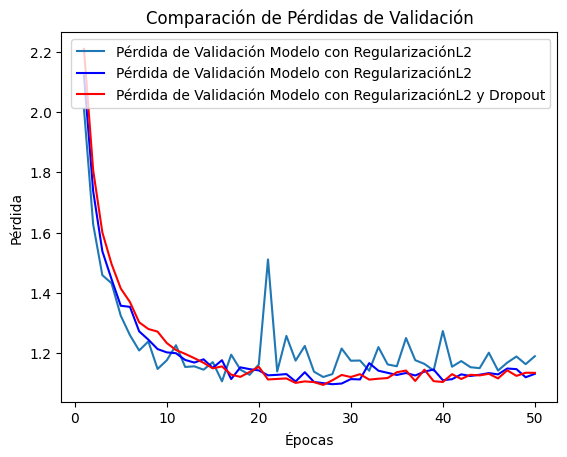

In [28]:
plt.plot(epochs, val_loss_values2, label='Pérdida de Validación Modelo con RegularizaciónL2')
plt.plot(epochs, val_loss_values3, 'b', label='Pérdida de Validación Modelo con RegularizaciónL2')
plt.plot(epochs, val_loss_values4, 'b', color='red', label='Pérdida de Validación Modelo con RegularizaciónL2 y Dropout')
plt.title('Comparación de Pérdidas de Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 196ms/step - accuracy: 0.4320 - loss: 3.0206 - val_accuracy: 0.5893 - val_loss: 2.1068
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5886 - loss: 1.9741 - val_accuracy: 0.6088 - val_loss: 1.7540
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6415 - loss: 1.6930 - val_accuracy: 0.6834 - val_loss: 1.5640
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6836 - loss: 1.5175 - val_accuracy: 0.7106 - val_loss: 1.4532
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7144 - loss: 1.3979 - val_accuracy: 0.7273 - val_loss: 1.3744
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7364 - loss: 1.2957 - val_accuracy: 0.7379 - val_loss: 1.3246
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7539 - loss: 1.2089 - val_accuracy: 0.7624 - val_loss: 1.2744
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7787 - loss: 1.1397 - val_accuracy: 0.7579 - 

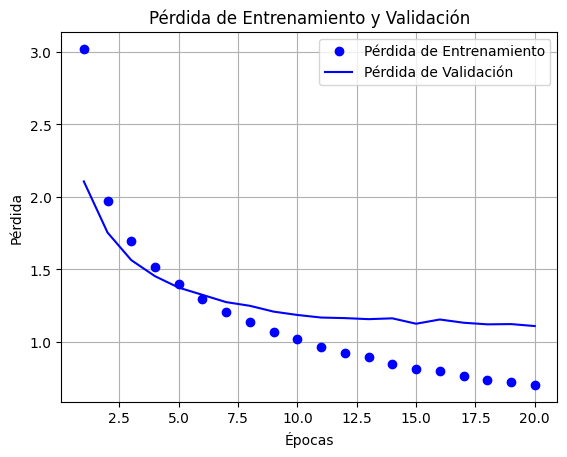

In [29]:
model5=models.Sequential()
model5.add(layers.Dense(64, activation="relu", input_shape=(10000,), kernel_regularizer=regularizers.l2(0.001)))
model5.add(layers.Dropout(0.5))
model5.add(layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)))
model5.add(layers.Dense(46, activation="softmax"))

model5.compile(optimizer="rmsprop", 
               loss="categorical_crossentropy", 
               metrics=["accuracy"])

modelo5=model5.fit(x_train, y_train, epochs=20, batch_size=512, validation_split=0.2)

modelo_dict5=modelo5.history
print(modelo_dict5)

loss_values5 = modelo_dict5['loss']
val_loss_values5 = modelo_dict5['val_loss']
epochs = range(1, len(loss_values5) + 1)

plt.plot(epochs, loss_values5, 'bo', label='Pérdida de Entrenamiento')
plt.plot(epochs, val_loss_values5, 'b', label='Pérdida de Validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.grid()
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

## Predicciones

In [60]:
for i in test_data[30]:
    print(reverse_word_index.get(i-3, "?"))

?
shr
16
cts
vs
22
cts
net
1
574
000
vs
1
725
000
sales
104
2
mln
vs
116
0
mln
avg
shrs
10
1
mln
vs
eight
mln
1st
half
shr
37
cts
vs
37
cts
net
3
675
000
vs
2
925
000
sales
244
5
mln
vs
230
6
mln
avg
shrs
10
0
mln
vs
eight
mln
reuter
3


In [61]:
test_labels[30]

np.int64(3)

In [62]:
y_test[30]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [57]:
Predicciones=model5.predict(x_test)
print(Predicciones[47])
print(np.sum(Predicciones[47]))

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[4.1956073e-07 2.9795449e-06 1.6908234e-06 6.1114994e-04 9.9912840e-01
 3.1038658e-07 1.7773039e-06 6.2039440e-08 4.6195368e-05 4.7614154e-07
 1.1926281e-06 1.7777701e-06 3.0467419e-07 1.8022735e-06 2.0849879e-07
 6.3193863e-07 6.7884212e-05 2.9472163e-05 8.3956131e-09 2.0717596e-05
 6.2511358e-06 3.5701149e-08 3.9765951e-08 3.3028136e-05 1.0210100e-06
 2.0582490e-06 6.4781239e-07 7.3163551e-07 2.7274561e-07 3.0497009e-07
 7.9284479e-07 2.0723464e-05 5.8210453e-06 1.3467177e-07 2.9946175e-08
 8.7734315e-07 2.4349515e-07 1.0038769e-06 5.4172563e-07 6.4130809e-06
 2.4336885e-07 9.5261413e-07 5.0644458e-09 8.1945650e-08 2.5564376e-07
 5.1290652e-08]
1.0


In [63]:
predic=np.argmax(Predicciones[30])
print(predic)

3


In [64]:
confianza = np.max(Predicciones[30])
print(confianza)

0.9795684


In [65]:
print(np.sum(Predicciones[30]))

1.0000001


In [59]:
# 1. Definimos la lista oficial de categorías (etiquetas) de Reuters
reuters_categories = [
    'cocoa','grain','veg-oil','wheat','copper','housing','money-supply',
    'coffee','sugar','trade','reserves','ship','cotton','carcass','crude',
    'nat-gas','cpi','money-fx','interest','gnp','meal-feed','alum','oilseed',
    'gold','tin','strategic-metal','livestock','retail','ipi','iron-steel',
    'rubber','heat','jobs','lei','bop','zinc','orange','pet-chem','dlr',
    'gas','silver','wpi','hog','lead','platinum','strategic-metal'
]
indice_noticia=30

# 2. Función para obtener la "Apreciación" del modelo
def obtener_diagnostico(indice_noticia, modelo, datos_test, etiquetas_reales):
    # Realizamos la predicción
    predicciones = modelo.predict(datos_test)
    
    # Obtenemos el índice con mayor probabilidad
    indice_predicho = np.argmax(predicciones[indice_noticia])
    probabilidad = np.max(predicciones[indice_noticia])
    
    # Buscamos los nombres en nuestra lista
    nombre_predicho = reuters_categories[indice_predicho]
    nombre_real = reuters_categories[etiquetas_reales[indice_noticia]]
    
    return nombre_predicho, nombre_real, probabilidad

# 3. Probamos con tu noticia 47
nombre, real, conf = obtener_diagnostico(indice_noticia, model5, x_test, test_labels)

print(f"--- Análisis de la Noticia {indice_noticia} ---")
print(f"Predicción del Modelo: {nombre.upper()} (Confianza: {conf*100:.2f}%)")
print(f"Etiqueta Real: {real.upper()}")

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
--- Análisis de la Noticia 30 ---
Predicción del Modelo: WHEAT (Confianza: 97.96%)
Etiqueta Real: WHEAT
